# Install Required Library

In [1]:
# Install library to handle imbalanced datasets
!pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np

# AWS S3
import boto3
from io import BytesIO

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve

# Handle imbalance
from imblearn.over_sampling import SMOTE

# Save / load model
import joblib

In [3]:
# Data Collection (Load Dataset from S3)
bucket_name = "iot-project-practice"
object_key = "ai4i2020.csv"

s3 = boto3.client("s3")
obj = s3.get_object(Bucket=bucket_name, Key=object_key)

df = pd.read_csv(BytesIO(obj["Body"].read()))

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
Duplicate rows: 0


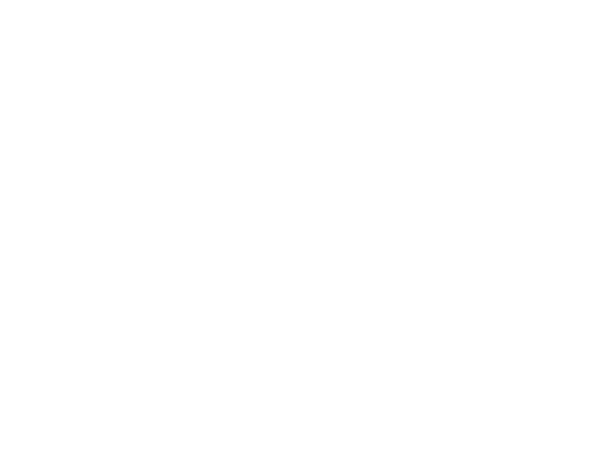

Machine failure
0    9661
1     339
Name: count, dtype: int64


In [4]:
# Data Understanding (EDA)
# Check missing values
print(df.isnull().sum())

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Target distribution
sns.countplot(x="Machine failure", data=df)
plt.title("Machine Failure Distribution")
plt.show()

print(df["Machine failure"].value_counts())

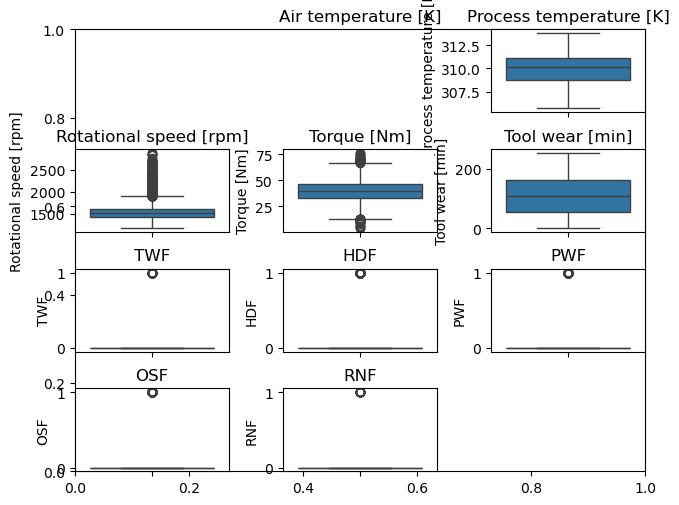

In [5]:
# Outlier Detection
import math

numerical_cols = df.select_dtypes(include=["int64","float64"]).columns
numerical_cols = numerical_cols.drop("Machine failure")

rows = math.ceil(len(numerical_cols)/3)

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols,1):
    plt.subplot(rows,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [6]:
# Outlier Handling (IQR Capping)
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

In [7]:
# Data Cleaning
# Remove identifiers
df = df.drop(["UDI","Product ID"], axis=1)

In [8]:
# Remove Data Leakage Columns
# These columns directly reveal the failure type
df = df.drop(["TWF","HDF","PWF","OSF","RNF"], axis=1)

In [9]:
# Reason:
# If any of these = 1 → Machine failure = 1.

# Keeping them would let the model cheat.

In [10]:
# Feature Engineering
# Encode categorical variable
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

In [11]:
# Feature / Target Split
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [12]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [13]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# Handle Imbalanced Data (SMOTE)
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

print(pd.Series(y_train_resampled).value_counts())

Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [15]:
# Model Training
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_resampled, y_train_resampled)

,n_estimators,400
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
# Predict Probabilities
probs = model.predict_proba(X_test_scaled)[:,1]

In [17]:
# Threshold Optimization
precision, recall, thresholds = precision_recall_curve(y_test, probs)

f1_scores = 2*(precision*recall)/(precision+recall)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

Best Threshold: 0.6952147966650932


In [18]:
# Final Predictions
predictions = (probs > best_threshold).astype(int)

In [19]:
# Model Evaluation
print(classification_report(y_test, predictions))
print("Accuracy:", accuracy_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.63      0.69      0.66        68

    accuracy                           0.98      2000
   macro avg       0.81      0.84      0.82      2000
weighted avg       0.98      0.98      0.98      2000

Accuracy: 0.9755


In [20]:
# Overfitting Check
train_pred = model.predict(X_train_scaled)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, predictions))

Train Accuracy: 0.9885
Test Accuracy: 0.9755


In [21]:
# Small gap → no overfitting.

In [22]:
# Predict New Machine Data
new_data = pd.DataFrame({
    "Air temperature [K]":[300],
    "Process temperature [K]":[310],
    "Rotational speed [rpm]":[1500],
    "Torque [Nm]":[55],
    "Tool wear [min]":[180],
    "Type_L":[0],
    "Type_M":[1]
})

new_scaled = scaler.transform(new_data)

prediction = model.predict(new_scaled)

print("Machine Failure Prediction:", prediction)

Machine Failure Prediction: [0]


In [23]:
# Save Model
joblib.dump(model, "machine_failure_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [24]:
# Load Model Later
model = joblib.load("machine_failure_model.pkl")
scaler = joblib.load("scaler.pkl")